# Algorithms 
This notebook will go through the algorithms which will be used to solve this problem and any decisions which went into them. As well as any other relevant decisions made as part of the modelling process.

In [1]:
%load_ext autoreload
%autoreload 2

## Multi-Agent Implementation
### Agents
This simulation involves multiple agents - across the greedy and genetic algorithm approach they use the same initialised agent population.

```python
    class Agent:
        name: str,
        city: Environment,
        characteristics: dict,
        key_manager,
        start_point: str | None = None,
        path: list | None = None,
        shortest_path: list | None = None,
        preferred_exits: list | None = None,
    ) -> None:
```

The agents are initialised according to a range of characteristics including:
* Walking Speed - note that not really using this.

#### Initialisation
Each agent is initialised with a start point, shortest path length and a random path (if not specified in the init). 

The random paths are generated by randomly selecting a neighbour from the start node and then continuing this random selection until an exit node is found. Once we have a path then any loops created in the process are removed. For example

`A -> B -> C -> D -> B -> E -> F` will become `A -> B -> E -> F`

In this implementation when we talk about path length this is referring to the number of NODES in the path not the traditional number of edges. For example ` A -> B -> C -> D` has a path length of 4.

#### Extensions:
Potential extensions for the agent class include:
* Compliance - each agent has a probability of following a greedy or genetic algorithms output.
* Preferred exits - each agent has a preference for the exit will use (e.g. local vs visitor).


## Random Seed Management
In order to ensure reproducibility in the code I have created a `KeyManager` which is used across all classes. Each experiement takes a seed value which is sent into the key manager to split so that a different non repeating sequence of keys. 

* This becomes important to ensure any agent chracteristics are the same across the two approaches.
* In the probability critieria checks in the genetic algorithm we get different values across the evolutions.

So...
* Its reproducible.
* Ensures fair comparison between GA and greedy.
* Independent experiements by running different seed values.
* Allows for statistical validation to compare across.


## Greedy Algorithm
The greedy algorithm is meant to represent the situation where everyone acts in a selfish manner. This as a result means there is no communication between agents and they just pick the shortest path to an exit.

### Definition & Origin
> What the algorithm is, where it comes from, and what class of problem it was designed for. 

TODO:
* Cormen et al. Introduction to Algorithms
* Shortest Path literature - Dijkstra (1959) (this is networkx under the hood)
* Use of greedy algorithms in graphs / networks

### Core Mechanism
> Step by step how it actually works — what decisions it makes, when, and based on what information.

[Networkx - Shortest Path](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path_length.html)

* Length of the path is always 1 less than the number of nods involved in the path as it follows edges.
* Uses dijkstra to compute the path length.

[Dijkstra](https://www.w3schools.com/dsa/dsa_algo_graphs_dijkstra.php):
* Used for solving single source shortest path problems for directed or undirected pths.
    * Single Source means one vertex is chosen to be the start.
* Doesn't work with negative edges.

How it works:
1. Set all initial distance for all vertices as: 0 for the source vertex and infinity for all the rest.
2. Create a set of unvisited nodes and add all nodes to it.
3. Chose an unvisited nodes with the shortest distance from the start to be the current node (i.e. intially this is the source node with distance 0).
4. For each of the current node's unvisited neighbours, calculate the distance from the source and update its distance (if lower than what exits).
5. We are now done with the current node so we mark it as visited.
6. Go back to step 3 as chose a new unvisited current node and keep repeating until all vertices have been visited.

*Watch the video on the below link when write up*.

**Since all your edges are weight 1 it will use BFS** - The Wikipedia article on Breadth-First Search is a clean reference for the mechanics of this so READ THIS.

To then extract the shortest path from a start to an end node, we can keep track of the `predecessors` array which keeps track of the previous node used to get the shortest path. For example if we have: `D (4) -> F (6) <- E (5)` where the numbers represent the path length to source, we could store node `D` as a predecessor for `F` in the node so we know we need to traverse back through `D` to find the source.

When we have nodes which have the same weighting (which is the case in this simulation), there is no formal rule on how to handle this but instead how they appear in the queue which in networkx is the order the edges were added to the graph.

In order to handle this issue, for the greedy algorithm we find all the shortest paths available and choose a random path from those short ones. This ensures we are allowing for the similar levels of random path choice as implemented in the genetic algorithm. In the real world if there were 2 shortests paths it is likely the population would split across these and not just pick the first (as the algorithm would do without the random selection).

### Key Parameters
> What controls the behaviour

There are limited arguments which decide on the behaviour of the greedy algorithm given we find all shortest paths the key decision maker becomes the random key which selects one of the shortest routes.

The greedy algorithm code takes 3 key arguments:
* `population` - the population of solutions including the list of agents which we need to find the shortest path for.
* `simulation_params` - list of agent and simulation parameters which are sent into the chromosome function to calculate the fitness function.
* `key_manager` - random key generator used across all classes to ensure reproducibility.

### Optimisation Scope
> e.g. greedy optimises locally and individually while GA globally and collectively.
* TODO: Look at literature on local vs global optimisation and selfish routing. Specifically search for Braess's Paradox 

### Computational Complexity
> How does runtime scale with problem size?

With V as the number of vertices in the graph, the time complexity for Dijkstra's algorithm is $O(V^2)$. This is because to find the next lowest distance takes $O(V)$ time and as we must search every node connected to the source this becomes $O(V^2)$. If we don't find the end node till the end this is the worst case scenario.

### Failure Modes
> Where does each algorithm break down? 
TODO: Search for literature on greedy routing in evacuation, selfish routing, and congestion in bottleneck networks.


In [45]:
import numpy as np
from tqdm import tqdm
from utils.environment import Environment

city = Environment(city_name='grid_city')
n_experiments = 3
num_agents = 30
params = {"congestion": True, "walking": False, "fitness": "max"}

rng = np.random.default_rng(123)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

In [65]:
from multi_agent_ga import KeyManager
from utils.agent import PopulationCreation
from utils.greedy import Greedy
from utils.plots import add_traversal_weights, plot_multiple_solutions

key_manager = KeyManager(seed=1234)
creator = PopulationCreation(city=city, pop_size=1, num_agents=num_agents, key_manager=key_manager)
# This ensures the agents all start from the same place so can compare how the random route selection varies
population, human_traits = creator.create_initial_population(simulation_params=params)

In [60]:
traversal_graphs = {}

for seed_idx in tqdm(range(n_experiments)):
    seed = algorithm_seeds[seed_idx]
    greedy_key_manager = KeyManager(seed=seed)
    greedy = Greedy(population=population, simulation_params=params, key_manager=greedy_key_manager)
    solution = greedy.solve(pick_first=False)
    chromosome = greedy.turn_into_chromosome_for_evaluation()
    congestion_score = np.mean(chromosome.congestion_score)
    G_traversal = add_traversal_weights(city.graph, solution)
    traversal_graphs[f'Seed {seed} → {congestion_score:.2f}'] = G_traversal

greedy_key_manager = KeyManager(seed=12345)
greedy = Greedy(population=population, simulation_params=params, key_manager=greedy_key_manager)
solution = greedy.solve(pick_first=True)
chromosome = greedy.turn_into_chromosome_for_evaluation()
congestion_score = np.mean(chromosome.congestion_score)
no_random_selection_G = add_traversal_weights(city.graph, solution)
traversal_graphs[f'No Random Path Selection → {congestion_score:.2f}'] = no_random_selection_G


100%|██████████| 3/3 [00:00<00:00, 40.56it/s]


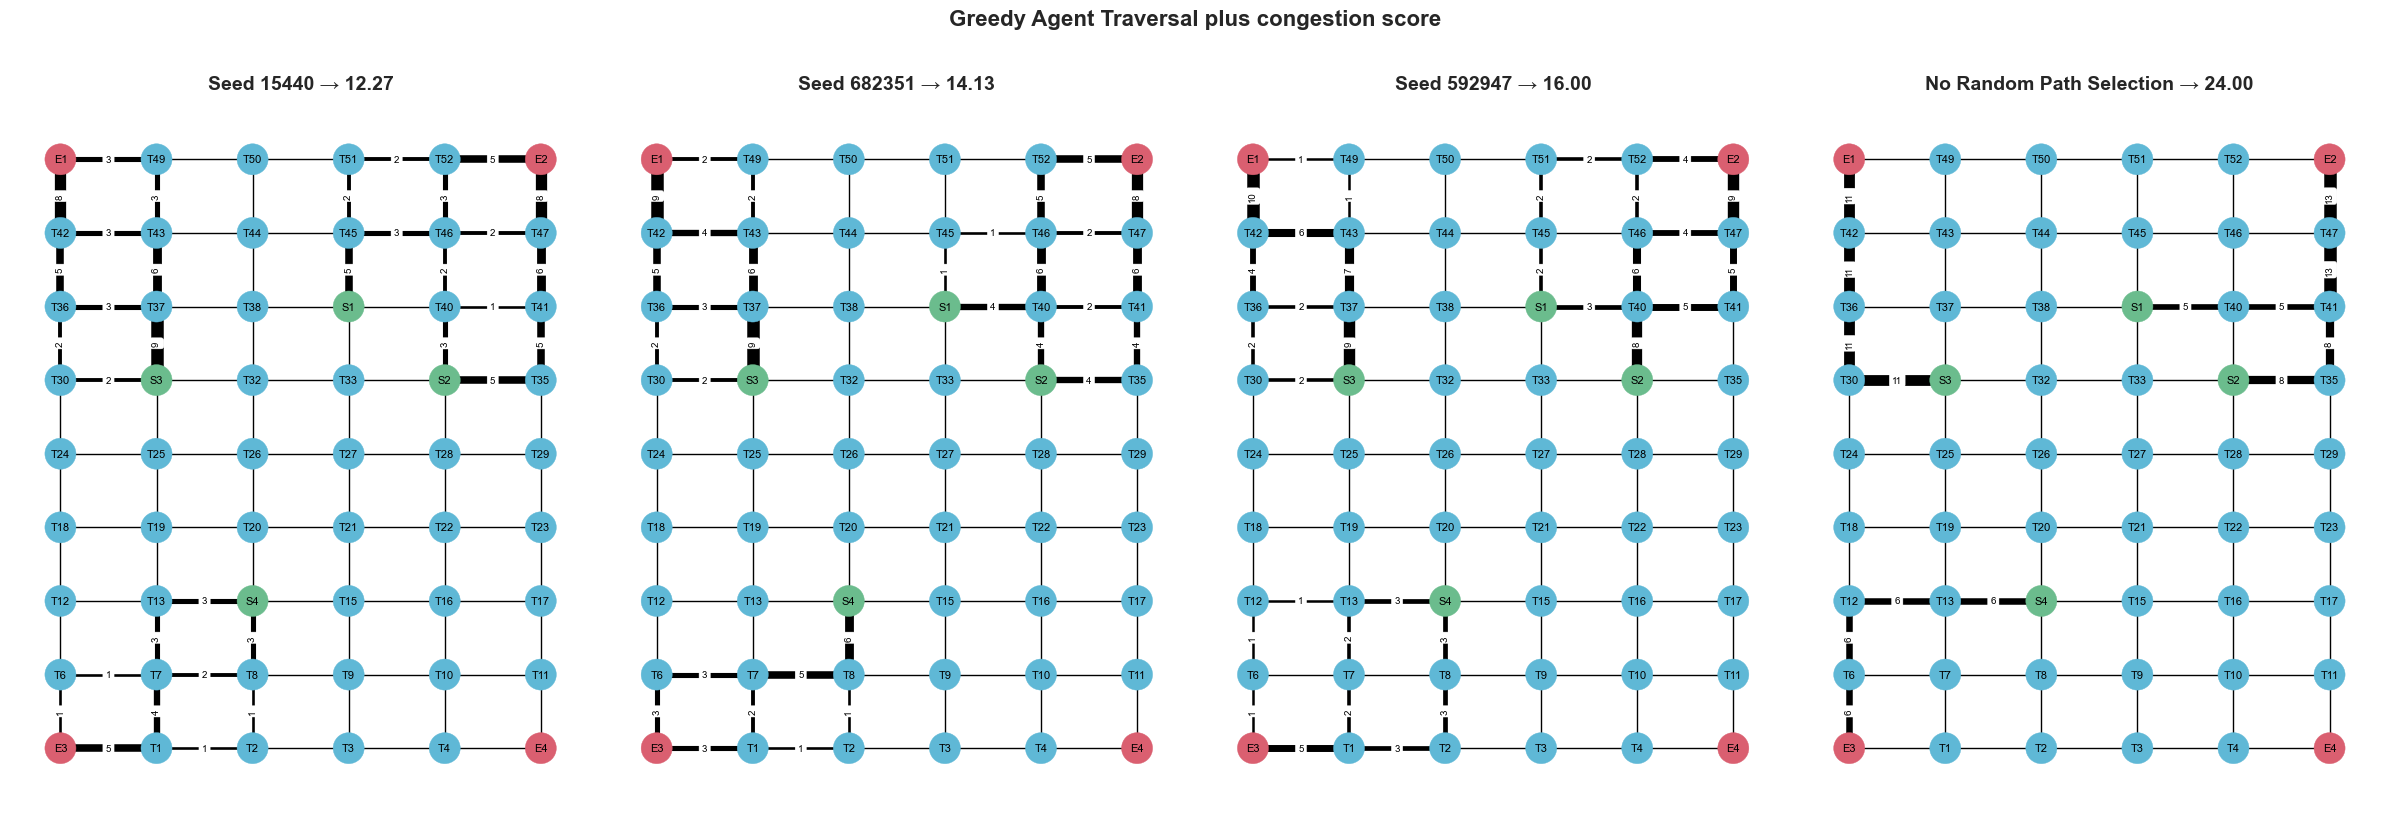

In [ ]:
plot_multiple_solutions(
    pos=city.pos, starts=city.starts, exits=city.exits,
    weighted_cities=traversal_graphs,
    plot_title='Greedy Agent Traversal plus congestion score'
)

The above plot shows how the agent paths vary with different random seeds for the greedy algorithm alone (the agents all start in the same position across the examples for fair comparison) (left 3) - whilst all still reaching the destination exit node with the same number of nodes. The right plot shows how the greedy solution would look if the first path found was used for every agent. The plots also show the congestion score for each example - the solution which selects the path for every agent is worse than those which allow for the varying shortest routes, whilst not being significantly worse that it still demonstrates the issues with greedy / selfish behaviour.

## Genetic Algorithm
The genetic algorithm is meant to represent the best case scenario where if agents were to communicate and forward think could result in the best scenario.

### Definition & Origin
> What the algorithm is, where it comes from, and what class of problem it was designed for. 
TODO:
* Holland (1975) "Adaptation in Natural and Artificial Systems" — this is the canonical original paper.
* Goldberg (1989) "Genetic Algorithms in Search, Optimization and Machine Learning

### Core Mechanism
> Step by step how it actually works — what decisions it makes, when, and based on what information.

Genetic algorithms take a randomised population of chromosomes which are sent through three key operators: Parent Selection, Crossover and Mutation. The psuedo code for this looks like:

```
Genetic Algorithm:
        Initialise random population;
        Evaluate the fitness of the population;

    while termination criterion is not met:
        Parent Selection - select good chromosomes by reproduction procedure;
        Crossover - crossover between parents with probability of crossover p_c;
        Mutation - with probability of mutation p_m;
        Evaluation - of the fitness of the population and select new population.
```

#### Chromosome Representation
> How is the solution encoded and how have others done this in multi-agent paths. Search "chromosome encoding multi-agent pathfinding" and "path representation genetic algorithm".

Each chromosome encodes a candidate solution as a set of all paths for each of the agents. For example, if we had 3 agents the chromosome solution would look like `[[A, B, C, D], [A, B, E, F], [B, E, F]]`. 
* A gene is a single position in chromosome so in this implemenetation represents one agent and the allele value is the agents path from start to end node.

The chromosomes are intialisedx from a population of agents, with each of the initial paths randomly generated at the point of initialisation. By using the exiting agents we ensure that all the agents start at the same points in the population (and with greedy algorithm), ensuring we are testing the exit route not the city set up. It is worth noting here (maybe somewhere else) that loops in paths are removed (probably need to justify why).

The chromosome then takes all the agent paths to calculate the fitness function (see below). Each of the chromosomes classes tracks the following information:
* `agents` - dictionary of agents and their corresponding index/name.
* `fitness` - the single value of the fitness function.
* `fitness_calc` - how to calculate the fitness functions e.g. maximum, mean or median value.
* `congestion_score` - list of the congestion delays for each agent.
* `path_lengths` - list of the lengths (i.e. number of nodes) for each agent.
* `path_times` - list of total time (i.e. number of nodes + congestion delay) for each agent. 

#### Fitness Function
> What is being measured and why. As well as how others have tried to do it, otherwise justify design choice.

The fitness function for this implementation is a combination of the `path_length` (i.e. the number of nodes) plus the `congestion_delay` for each agent from over crowding across nodes.

##### Path Length
The path length counts the number of nodes from start to end of the path i.e. `[A, B, C, D, E]` would be a path length of 5. In addition, the agents have walking speed characteristics, this represents how many "time steps" it takes for an agent to move from one node to another. For example, if we have a path length of 5, an agent with a speed of 1 with have a path length of 5 (i.e. moves quickly through the graph), whereas an agent with a speed of 2 will have a path length of 10 (i.e. moves slower through the graph).

##### Congestion Delay
The congestion delay is weakly time dependent (non-causal), for example if we have an agent which gets delayed at its first node, the delay doesn't propagate forward, i.e. this will not effect the calculations for the next node. So the number of agents at a node at a certain position is based on the node in that position in the path.

So to calculate node congestion we identify how many agents are at each node at each node position. So for example if we have the following 3 agents: `[A, B, C], [A, D, E], [B, D, E]`. If we then imagine the node capacity is set as 1, for the following path positions we get the number of agents at each node:
1. `{A: 2, B: 1}`
2. `{B: 1, D: 2}`
3. `{C: 1, E: 2}`

These node occupancies are then used to calculate the congestion delay for each agent. The congestion delay is calculated as the the over capacity value. This over capacity value is set for all agents. So in the above example, the congestion delays we get are:
* Agent 1 - 1 [over capacity at position 1] + 0 [no capacity exceeding at position 2] + 0 [no capacity exceeding at position 3] = 1
* Agent 2 - 1 [over capacity at position 1] + 1 [over capacity exceeding at position 2] + 1 [over capacity exceeding at position 3] = 3
* Agent 3 - 0 [no capacity at position 1] + 1 [over capacity exceeding at position 2] + 1 [over capacity exceeding at position 3] = 2

So agent 1 recieved the best congestion delay as is only over capacity in position 1.

#### Parent Selection, Crossover, Mutation & Survivor Selection
> How new solutions are generated, each operator should be described and justified.

##### Parent Selection
The parent selection in this implementation is done using `roulette selection`. Roulette selection is the method of ordering the solutions based on their fitness value and then dividing that by the total population fitness. This method means that better solutions have a higher chance of being selected (proportional to its fitness value). Ensuring that the worse solutions still have the chance to be selected ensures we have diversity in the population and we can avoid the local optima.

One issue with roulette selection is that if one chrosomoe has significantly higher fitness than others it will dominate a large propotion of the wheel, which could cause premature convergence.
❌ Map the values across the fitness functions to understand if this is going to be an issue. Also check if all chromosomes have similar fitness as this can just become uniform. 
* Check the std/mean - if this is less than 5% the fitness is too similar and if >30% then one solution dominates.
* Check the max/min fitness if - if < x1.5 the results are too similar and if > x10 the best solution absorbs the wheel.
* Check the proportion of the wheel the best chromosome makes up max/total fitness - ideally below 20% and definitely no more than 40%.

**Alternative methods:**
* Tournanment Selection - randomly sample K chromosomes and the fittest among them wins. ❌ Might be worth trying this as says its most widely used in practice.
* Rank Selection - instead of raw fitness ranks are used and wheel slices based on rank are used. This solves the scaling problem.

##### Crossover
The chromosome crossover is done across agents, so given two parents we first of all check if the crossover happens or not by generating a number and if its less than crossover probability then we perform crossover.

For a set of parents we loop through the agents in each parent and check for an overlapping node (excluding start and exit nodes). If there is no overlap between the agents then the parent paths are just carried forward. If there are overlapping nodes we randomly select one and the paths between the two agents are swapped. For example:
* Parent 1 - `[A, B, C, D]`
* Parent 2 - `[E, F, B, G, C, H]`
* There are two overlapping nodes `[B, C]` (excluding start and exit nodes). We randomly select one of these, lets say `B` then the two children become: `[A, B, G, C, H]` and `[E, F, B, C, D]`. 

By crossing over at an overlapping node we ensure that the routes remain valid, other methods risk this not being the case and often resulting in reverting to greedy techniques to "fix" the path.

**Alternative Methods:**
* Single Point Crossover - we could have just switched full agents across chrosomes for example `C1 = [A11, A12, A13]` and `C2 = [A21, A22, A23]` if we switch at a single agent index (say position 2) the children become `[A11, A22, A23]` and `[A21, A12, A13]`. This is limited as we ignore anything to do with the path and just presume other agents will have improved paths from this swap.
** Two Point Crossover - similar issues to above.

##### Mutation
Agent mutation unlike crossover happens at a chromosome agent level, this is so that we can introduce small changes to the paths directly. This means that some agents in a chrosomome might mutate while others might not.

In this implementation, when mutation occurs it represents the consideration of changing the exit the agent has currently selected. This can include the current exit they have - this is because the mutation should allow for mutations to be neutral.

So for an agent which is going to mutate we first randomly select a new exit (which can include current). We then select a point on the path to which we will create a new path to the new exit - this means that even if the exit is the same the path could still mutate. In order to create this new path we utilise `epsilon greedy path selection` - this process involves at each step in the traversal the agent either takes a greedy step towards the exit or randomly selects another node (excluding exit nodes) according to the epsilon value.

This approach ensures valid routes, keeps some of the early path routes and uses epsilon to balance exploration vs exploitation.

**Alternative Options:**
* Reverse a Segment - reverse a random segment of a path (2-opt) which is common in TSP and then fixing the path. This approach might not work given there are defined path edges in the graph resulting in invalid paths.
* Node Swap - replace a random node in the path with a different neighbouring node. This could be more sutable swaps as it only alters one step rather than the entire path.
* Entire Path Regeneration - completely regenerate the agents path using epsilon greedy. This would ensure maximum exploration but is very destructive.

##### Survivor Selection
The selection stage of the genetic algorithm decided which chromosomes will be taken forward into the next generation / evolution of the algorithm. There are two options to do this:
1. Elitism - all chromosomes from the previous generation plus all new children are available to pick from and the top `population_size` are taken to the next generation.
2. Only Children - only the children chromosomes are carried forward to the next generation.

The elitist approach ensure that we never lose the best solution we have found, however if we have a lot of strong parents then this can slow down exploration. However by only keeping children we force the population to evolve, but we do risk losing parents.

❌ Plot the proporation of parents vs children in elite survivor selection. Try these approaches with different number of evolutions as well (children only might require more).

#### Convergence Criteria
> How do you decide the GA is finished (# generations, fitness plateau, time limit). Search  "genetic algorithm convergence criteria" and "premature convergence genetic algorithm".

Currently the exit criteria for the algorithm is simply hitting the maximum number of generations. 
❌ Try implementing the fitness plateau of X for K generations.
❌ Need to think about these across the different cities.

### Key Parameters
> What controls the behaviour
The key parameters which influence the genetic algorithm are:

| Parameters | Description | Current Value | Experiements To Do |
| ---------- | ----------- | ------------- | ----- |
| Crossover Probability | The probability two parent chromosomes will exchange genetic material to product a child. This controls how much of the exiting populations knowledge is combined into new solutions. |  | ❌ Run extreme values and middle ground values to see how the congestion score varies across the cities. |
| Mutation Probability | The probability that a gene in a chromosome is randomly altered, this ensures maintaining diversity in the poulation. |  | ❌ Sweep across range of values especially on the bottleneck city. |
| Population Size | The number of candidate solutions maintained in each generation. Larger populations explore more of the solution space but increases computational cost. |  | ❌ Try range of valus [1. 5, 10, 20, 50, 100] showing congestion vs runtime. |
| Random Seed | This is the seed sent into the key manager to ensure reproducibility across the different simulations. | NA | ✅ Show the different paths generated by different seeds. ❌ Run a large amount of seeds to show the results are similar (robust and not seed sensitive) |
| Maximum Evolutions | This is the termination critieria for how many generations are run before returing the best solution - representing the computational budget allocated to the search. |  | ❌ Plot the convergence curve, run this for all cities. |
| Epsilon | Controls the probability of making a greedy move vs a random move in the path construction from a mutation. High values mean the agent always moves greedily towards the exit, whereas low values are equivalent to a random walk. |  | ❌ Experiment with different values of this in 0.2 increments looking for congestion score performance, convergence speed and variance across seeds. |

### Optimisation Scope
The fitness function evaluates the entire set of agents paths simultaneously rather than independently. This means GA can discover solutions where some agents take suboptimal routes which benefit the collective as a whole.

TODO - Braess Paradox.

### Information Requirements
The genetic algorithm needs more information than greedy:
* Population Initialisation - city graph including starts and exits.
* Fitness function - agent paths and agent congestion.
* Input parameters - explained above.


### Computational Complexity
How does runtime scale with problem size?
* Initisation - scales with population size and number of agents.
* Fitness Evaluation - this is the most expensive operation as its run once per agent per chromosome per generation.
* Crossover - scales with population size and path length.
* Mutation - scales with population size and path length.
* Survivor Selection - sorting operation scales with population size.

`O(generations × population_size × agents × path_length)` 
* Compare with greedy `O(agents × path_length)` i.e. GA comes with significant computational cost.

❌ Add time tracking component to be able to comment on this.

### Failure Modes
TODO:
Search "genetic algorithm premature convergence" and "diversity loss genetic algorithm". Your pop_size=1 bug from earlier is actually a concrete example of degenerate GA behaviour you can reference

* Premature convergence - i.e. add some testing in for evolutions and no improvement.
* Parameter Sensitivity - i.e. why sensitivity analysis is important.


In [70]:
from utils.genetic_algorithm import GeneticAlgorithm

traversal_graphs_ga = {}
population_size = 20

for seed_idx in tqdm(range(n_experiments)):
    
    # This ensures the agents all start from the same place so can compare how the random route selection varies (hopefully)
    key_manager = KeyManager(seed=1234)
    creator = PopulationCreation(city=city, pop_size=population_size, num_agents=num_agents, key_manager=key_manager)
    population, human_traits = creator.create_initial_population(simulation_params=params)
    
    seed = algorithm_seeds[seed_idx]
    ga_key_manager = KeyManager(seed=seed)
    ga = GeneticAlgorithm(
        exit_criteria={"max_evolutions": 20},
        pop_size=population_size,
        key_manager=ga_key_manager,
        num_agents=num_agents,
    )
    
    evolution = 1
    terminate = ga.extract_termination_criteria(evolution=evolution)

    avg_walking_speed = np.mean(human_traits["walking_speeds"])

    while not terminate:
        parents = ga.parent_selection(population=population)
        children = ga.chromosome_crossover(parents=parents)
        mutated_children = ga.agent_mutation(children=children)
        population = ga.survivor_selection(
            children=mutated_children, old_population=population, keep_best=True
        )

        # 7 Termination
        evolution += 1
        terminate = ga.extract_termination_criteria(evolution=evolution)

    final_solution = sorted(population, key=lambda c: c.fitness)[0]

    congestion_score = np.mean(final_solution.congestion_score)
    G_traversal = add_traversal_weights(city.graph, final_solution.agents)
    traversal_graphs_ga[f'seed {seed} → {congestion_score:.2f}'] = G_traversal

100%|██████████| 3/3 [00:25<00:00,  8.34s/it]


In [71]:
traversal_graphs_ga

{'seed 15440 → 3.20': <networkx.classes.graph.Graph at 0x1276376e0>,
 'seed 682351 → 3.20': <networkx.classes.graph.Graph at 0x1276357f0>,
 'seed 592947 → 3.20': <networkx.classes.graph.Graph at 0x127636210>}

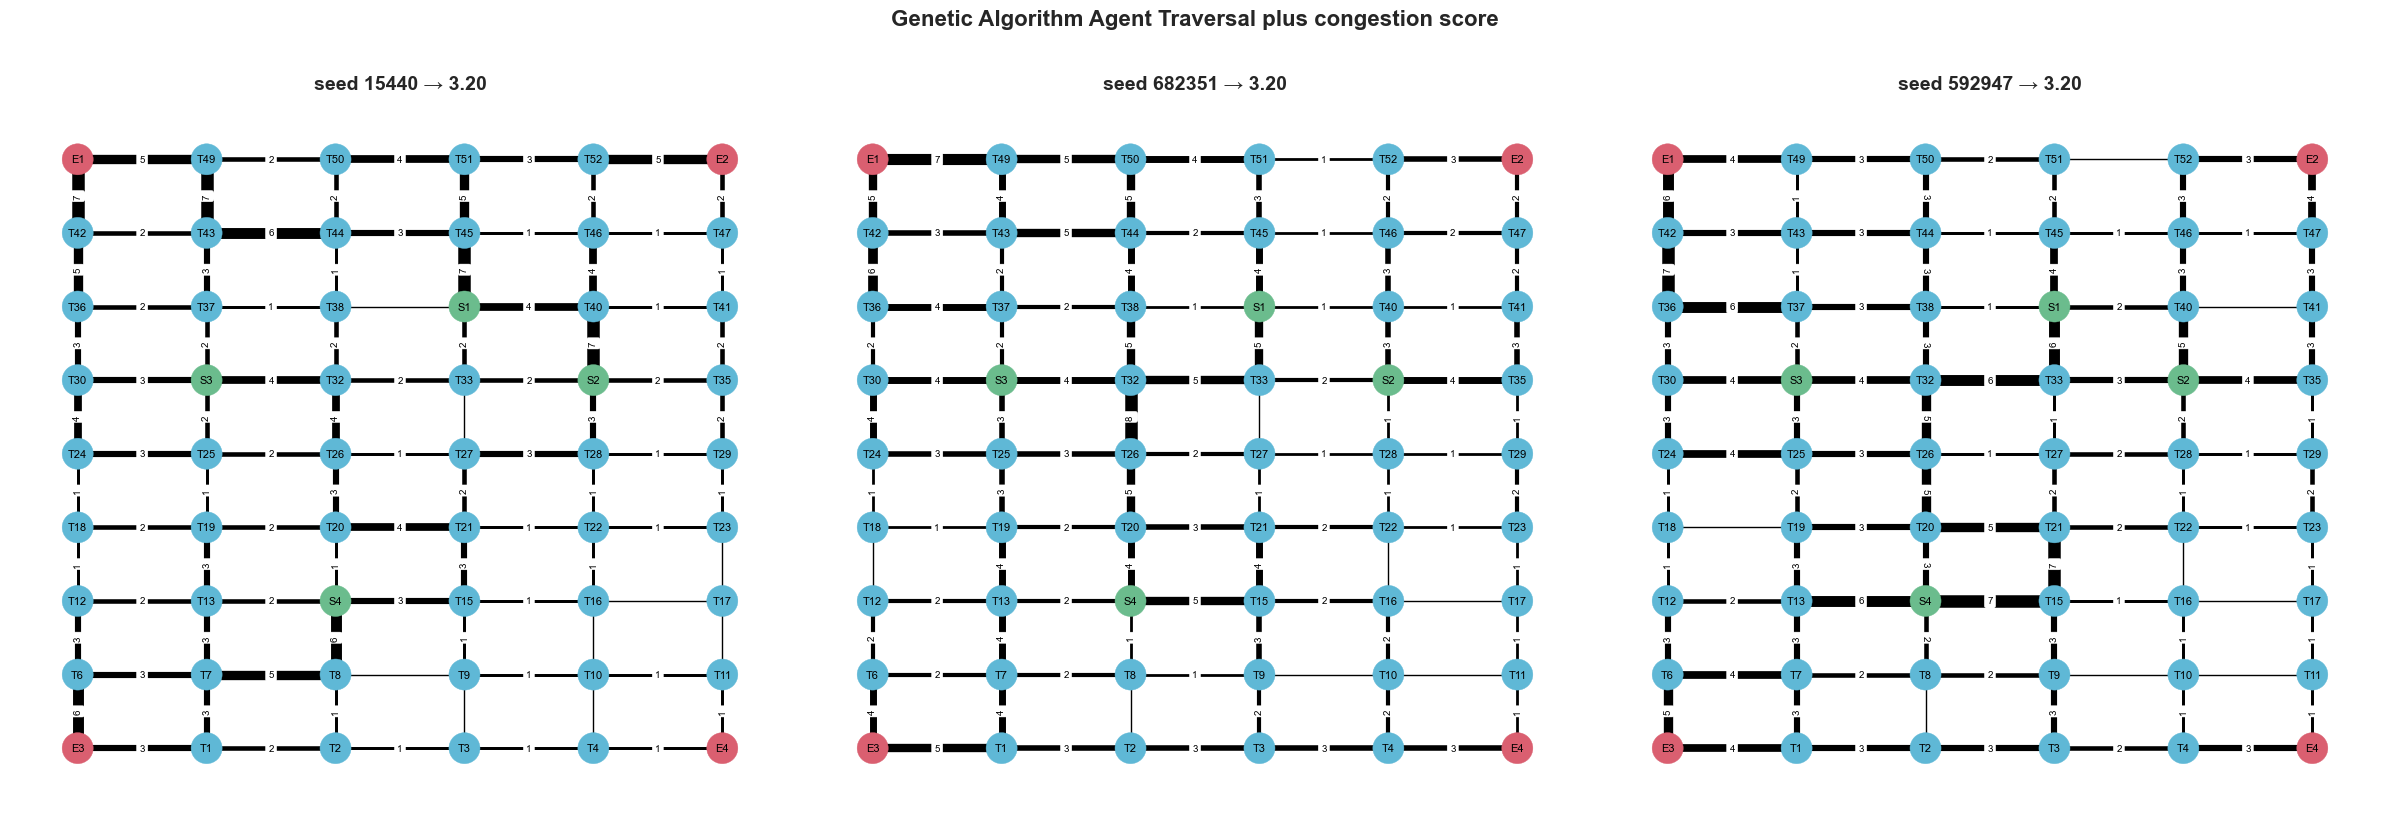

In [72]:
plot_multiple_solutions(
    pos=city.pos, starts=city.starts, exits=city.exits,
    weighted_cities=traversal_graphs_ga,
    plot_title='Genetic Algorithm Agent Traversal plus congestion score'
)

The above plots show how the genetic algorithm output varies across the different seeds.

### Agent Starting Position Validation
In order for the results to be comparable we have to ensure the agents are starting in the same places across the two simulations.
The below functions are snippets of the full simulations functions where they just create the population for each.

In [81]:
def simulate_greedy_population(
    num_agents: int,
    simulation_params: dict,
    city: Environment,
    algorithm_seed: int,
) -> None:
    key_manager = KeyManager(seed=algorithm_seed)
    creator = PopulationCreation(
        city=city, pop_size=1, num_agents=num_agents, key_manager=key_manager
    )
    population, _ = creator.create_initial_population(
        simulation_params=simulation_params
    )

    return population


def simulate_ga_population(
    city: Environment,
    num_agents: int,
    population_size: int,
    algorithm_seed: int,
    simulation_params: dict,
):

    # 1 Generate the population
    key_manager = KeyManager(seed=algorithm_seed)
    creator = PopulationCreation(
        city=city, pop_size=population_size, num_agents=num_agents, key_manager=key_manager
    )
    population, _ = creator.create_initial_population(
        simulation_params=simulation_params
    )

    return population

greedy_pop = simulate_greedy_population(num_agents=num_agents, simulation_params=params, city=city, algorithm_seed=algorithm_seeds[0])
ga_pop = simulate_ga_population(num_agents=num_agents, simulation_params=params, city=city, algorithm_seed=algorithm_seeds[0], population_size=population_size)

#### Check 1 - are the agents starting in the same positions across the genetic algorithm?

In [82]:
chromosome1_agent_starts = [agent.start_point for agent in ga_pop[0].agents.values()]

match = []
for idx in range(1, len(ga_pop)):
    agent_starts = [agent.start_point for agent in ga_pop[idx].agents.values()]
    match_starts = chromosome1_agent_starts == agent_starts
    match.append(match_starts)
    
if all(match):
    print('All population agents start in the same location :)')
else:
    print('Not all agents start in the same place - go find out why :(')

All population agents start in the same location :)


#### Check 2 - are the agents starting in the same positions across the genetic algorithm and the greedy?

In [83]:
ga_agent_starts = [agent.start_point for agent in ga_pop[0].agents.values()]
greedy_agent_starts = [agent.start_point for agent in greedy_pop[0].agents.values()]

match = chromosome1_agent_starts == agent_starts
    
if match:
    print('Greedy & GA agents start in the same place :)')
else:
    print("Greedy & GA agents don't start in the same place  - go find out why :(")

Greedy & GA agents start in the same place :)
